In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import math
import pandas as pd
import bisect
import uuid
from enum import Enum

from fame import *

In [2]:
# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [3]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

In [4]:
comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
    ground_stations=ground_stations,
    satellites=satellites,
    min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
    max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+dt.timedelta(seconds=3600*24*2),
    passes_error_s=60,
    passes_horizon_deg=20
)

In [5]:
stride_s = 60
plot_range_s = 10800

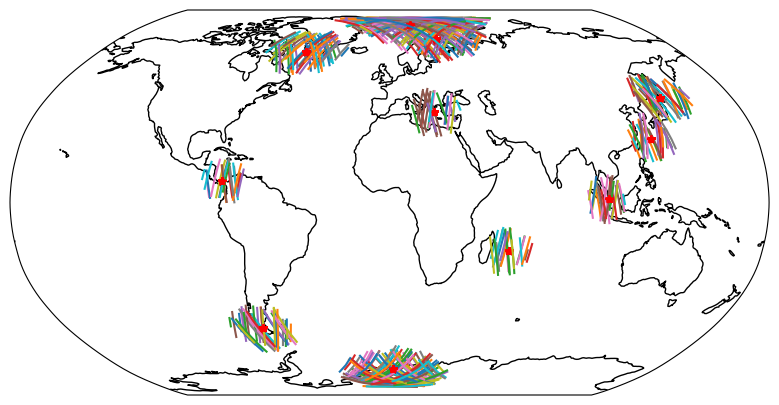

In [6]:
# comm_opportunities_by_sat

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

ground_station_dict = {gs.name: gs for gs in ground_stations}

for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
    for (ground_station, satpass) in sat_passes_with_gs:
        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
        # ax.coastlines()
    
        # request location
        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
        # ground_station = ground_station_dict[gs]
        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    
        # Where is the satellite?
    
        _dt = dt.timedelta(seconds=stride_s)
        time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
    
        _orbit = satellite.orbit
        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
        axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    
        # Where is the satellite looking?
        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
        # axglobal.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # ax.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # request_counter += 1

In [7]:
# map = Basemap(projection='robin',lon_0=0,resolution='c')
# map.drawcoastlines()

# for satellite in llas:
#     map.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]], '.', latlon=True)

In [8]:
# The first thing you do with a new batch of satellites: plot ground tracks. The simple way.



time_steps_for_plotting = [dt.datetime.now(dt.timezone.utc).replace(tzinfo=None) + dt.timedelta(seconds=stride_s*i) for i in range(int(plot_range_s/stride_s))]

llas = {}
for satellite in satellites:
    llas[satellite] = [satellite.orbit.get_lonlatalt(t) for t in time_steps_for_plotting]


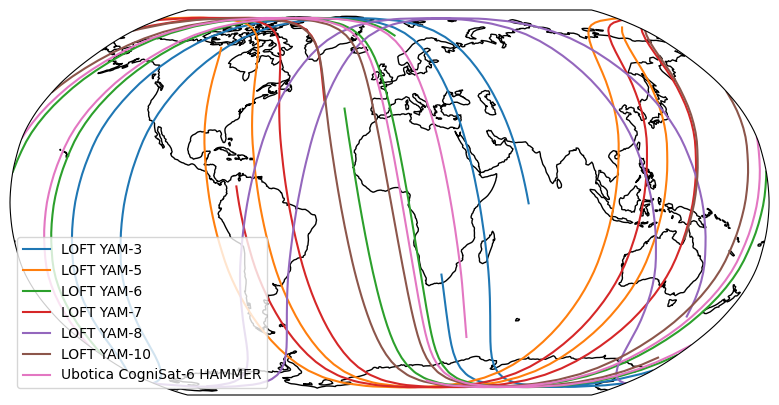

In [9]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for satellite in llas:
    ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite.name)
ax.legend()

In [10]:
jpl_lla = [-118.1730155, 34.2009478, 0.329]
passes_horizon_h = 12
passes_error_s = 60
passes_horizon_deg = 0.

passes = {}

for satellite in satellites:
    passes[satellite] = satellite.orbit.get_next_passes(dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),passes_horizon_h,jpl_lla[0],jpl_lla[1],jpl_lla[2],passes_error_s,passes_horizon_deg)

In [11]:
for satellite, passlist in passes.items():
    if len(passlist):
        print("{} passes for {}".format(len(passlist), satellite.name))
        for satpass in passlist:
            print("Start: {}. End: {}. Max altitude: {}".format(satpass[0], satpass[1], satpass[2]))
    else:
        print("No passes for {}".format(satellite.name))

3 passes for LOFT YAM-3
Start: 2025-11-25 01:06:09.232927. End: 2025-11-25 01:16:50.400483. Max altitude: 2025-11-25 01:11:37.937648
Start: 2025-11-25 02:40:42.504410. End: 2025-11-25 02:45:49.240910. Max altitude: 2025-11-25 02:43:15.949342
Start: 2025-11-25 11:32:40.592216. End: 2025-11-25 11:41:47.985621. Max altitude: 2025-11-25 11:37:13.470604
3 passes for LOFT YAM-5
Start: 2025-11-25 03:24:08.016226. End: 2025-11-25 03:27:54.881333. Max altitude: 2025-11-25 03:26:01.278842
Start: 2025-11-25 04:52:45.076067. End: 2025-11-25 05:03:42.868790. Max altitude: 2025-11-25 04:58:12.823329
Start: 2025-11-25 06:28:18.791776. End: 2025-11-25 06:34:50.199494. Max altitude: 2025-11-25 06:31:34.337399
3 passes for LOFT YAM-6
Start: 2025-11-25 08:13:16.373887. End: 2025-11-25 08:17:09.291173. Max altitude: 2025-11-25 08:15:12.766369
Start: 2025-11-25 09:41:54.149929. End: 2025-11-25 09:52:58.182377. Max altitude: 2025-11-25 09:47:30.137303
Start: 2025-11-25 11:17:22.637742. End: 2025-11-25 11:24

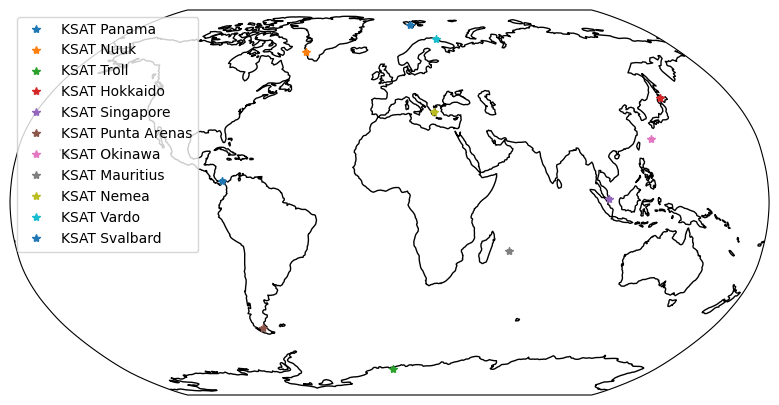

In [12]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for station in ground_stations:
    ax.plot(station.lon_deg, station.lat_deg,'*',transform=ccrs.Geodetic(), label=station.name)
ax.legend()

In [13]:
print(get_elevation_usgs(-118,34))
print(get_elevation_from_open_elevation(-118,34))

295.55368042
307.0


In [14]:
min_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time = min_time + dt.timedelta(hours=24)

os = ObservationRequest(-118,34, alt_km=0.307, min_time=min_time, max_time=max_time)

In [15]:
obs_requests = [
    ObservationRequest(-118., 34., min_time=min_time, max_time=max_time, alt_km=0.307),
    ObservationRequest(8., 45., min_time=min_time, max_time=max_time, alt_km=0.216),
    ObservationRequest(-80., 34., min_time=min_time, max_time=max_time, alt_km=0.041),
]

In [16]:
observation_opportunities = find_observation_opportunities(obs_requests, satellites)

In [17]:
# for request, passes in observation_opportunities.items():
#     for satellite, satpasses in passes.items():
#         for satpass in satpasses:
#             print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))

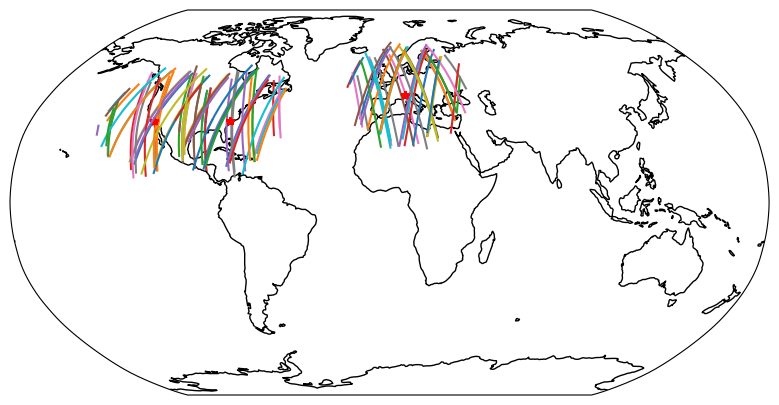

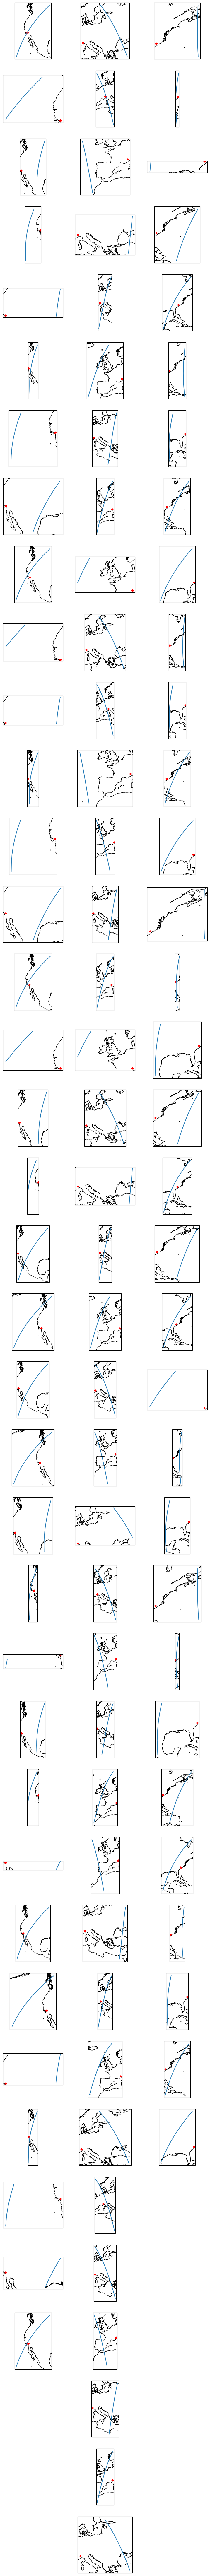

In [18]:
_plot_offset_deg = 20

request_counter = 1
pass_counter = 0

request_number = len(observation_opportunities)
max_num_passes = max([sum([len(passes) for passes in all_passes.values()]) for all_passes in observation_opportunities.values()])

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3*max_num_passes))

for orequest, all_passes in observation_opportunities.items():
    pass_counter = 0
    for satellite, passes in all_passes.items():
        for satpass in passes:
            ax = fig.add_subplot(max_num_passes, request_number, request_counter + request_number*pass_counter, projection=ccrs.Robinson())
            pass_counter += 1
            # ax.set_global()
            # ax.set_extent((float(orequest.lon_deg)-_plot_offset_deg, float(orequest.lon_deg)+_plot_offset_deg, float(orequest.lat_deg)-_plot_offset_deg, float(orequest.lat_deg)+_plot_offset_deg))
            ax.coastlines()
        
            # request location
            ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

            # Where is the satellite?

            _dt = dt.timedelta(seconds=stride_s)
            time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

            # for satellite, orbit in satellites.items():
            _orbit = satellite.orbit
            _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
            ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
            axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

## Pick the best request. Greeedy, no conflicts or anything

In [19]:
best_request = {r: None for r in obs_requests}

for request, passes in observation_opportunities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request[request] = (_best_satellite, _best_pass)

In [20]:
best_request

{Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-25 00:33:45.995859 to 2025-11-26 00:33:45.995859 with RGB: (LOFT YAM-7,
  Pass start: 2025-11-25 06:42:45.496980, highest: 2025-11-25 06:48:05.334773, fall: 2025-11-25 06:53:32.499480),
 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-25 00:33:45.995859 to 2025-11-26 00:33:45.995859 with RGB: (Ubotica CogniSat-6 HAMMER,
  Pass start: 2025-11-25 00:56:01.688975, highest: 2025-11-25 01:00:45.315068, fall: 2025-11-25 01:05:30.016347),
 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-11-25 00:33:45.995859 to 2025-11-26 00:33:45.995859 with RGB: (LOFT YAM-8,
  Pass start: 2025-11-25 04:29:50.011065, highest: 2025-11-25 04:35:45.746339, fall: 2025-11-25 04:41:38.287033)}

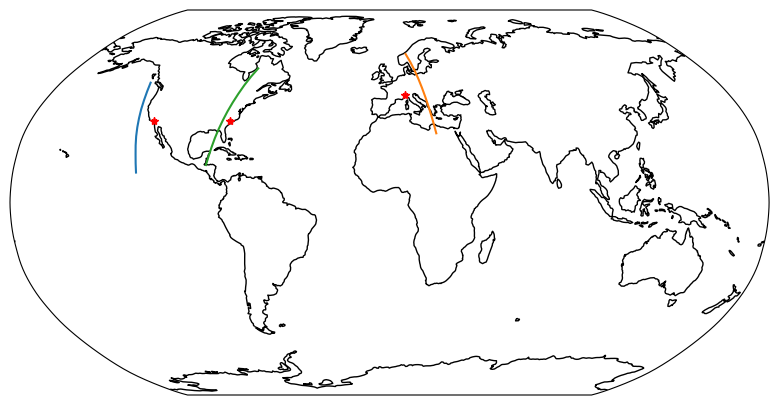

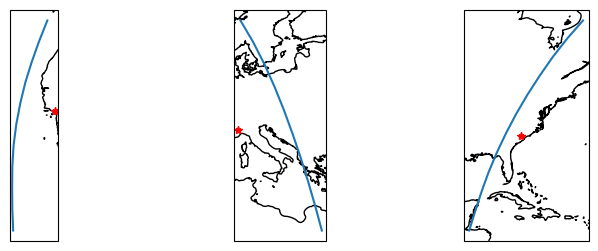

In [21]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3))

for orequest, (satellite, satpass) in best_request.items():
    ax = fig.add_subplot(1, request_number, request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    # for satellite, orbit in satellites.items():
    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

# More locations

Read a DB of world cities. Generate a good number of locations.

In [22]:
cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

In [23]:
sampled_world_cities = cities_of_the_world.sample(n=100,weights='population',axis=0, random_state=0)

In [24]:
one_hundred_sampled_cities = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities.iterrows()
]

In [25]:
observation_opportunities_cities = find_observation_opportunities(one_hundred_sampled_cities, satellites)

In [26]:
best_request_cities = {r: None for r in one_hundred_sampled_cities}

for request, passes in observation_opportunities_cities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request_cities[request] = (_best_satellite, _best_pass)

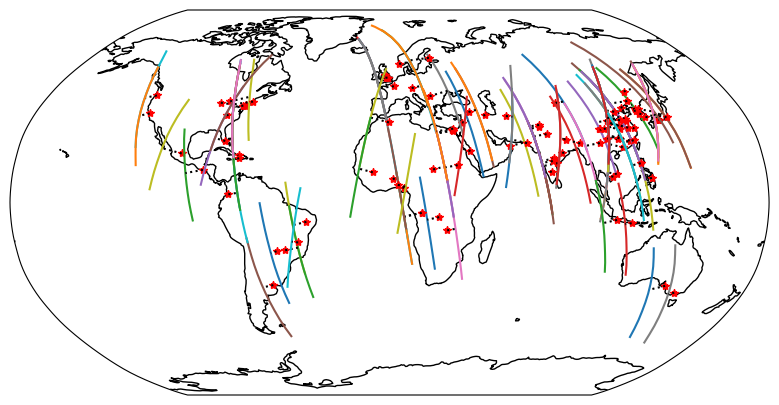

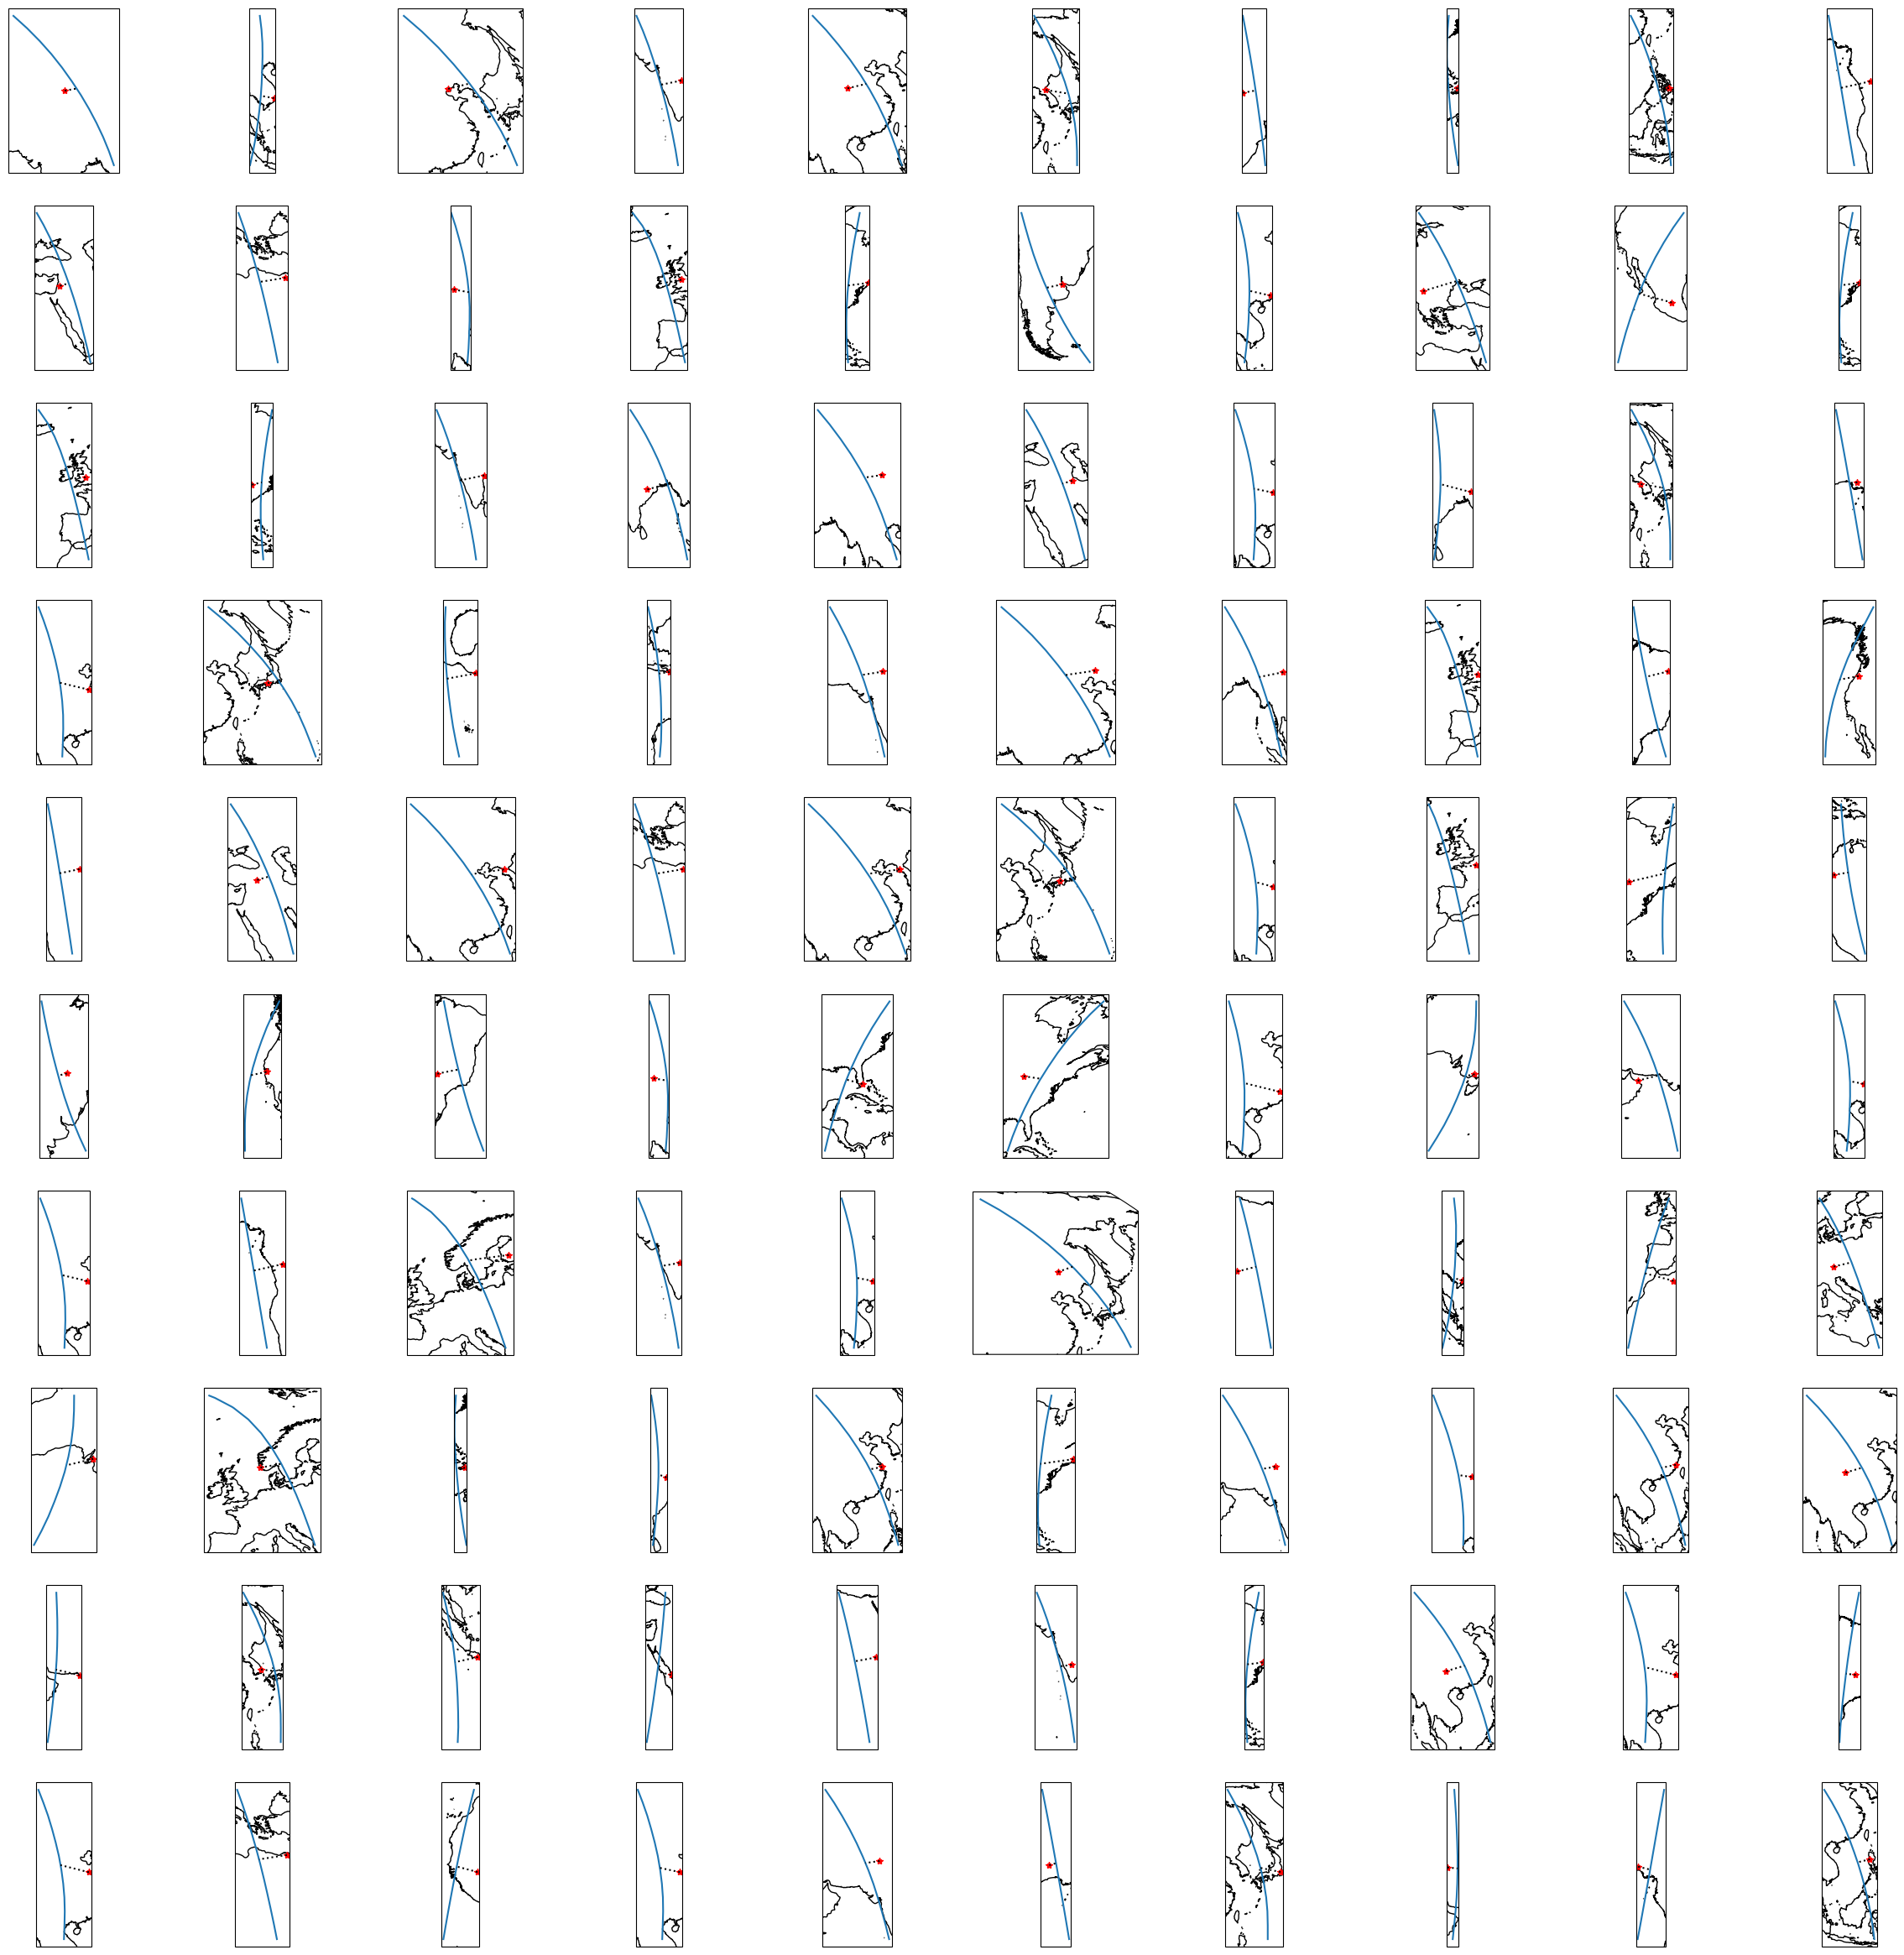

In [27]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities_cities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for orequest, (satellite, satpass) in best_request_cities.items():
    ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

    # Where is the satellite looking?
    _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
    axglobal.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    ax.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    
    request_counter += 1